In [18]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [19]:
class Config:
    
    BASE_DIR = "/kaggle/input/glucoma-detection/Drishti-GS1_files/Drishti-GS1_files"
    TRAIN_IMG_DIR = f"{BASE_DIR}/Training/Images"
    TRAIN_GT_DIR = f"{BASE_DIR}/Training/GT"
    TEST_IMG_DIR = f"{BASE_DIR}/Test/Images"
    TEST_GT_DIR = f"{BASE_DIR}/Test/Test_GT"
    DIAGNOSIS_FILE = "/kaggle/input/glucoma-detection/Drishti-GS1_files/Drishti-GS1_diagnosis.xlsx"
    
    IMG_SIZE = 256
    IN_CHANNELS = 3
    NUM_CLASSES = 2  
    
    BATCH_SIZE = 4
    LEARNING_RATE = 1e-2
    NUM_EPOCHS = 100
    EARLY_STOPPING_PATIENCE = 10
    
    SEED = 42

config = Config()

torch.manual_seed(config.SEED)
np.random.seed(config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(config.SEED)

In [20]:
class DrishtiDataset(Dataset):
 
    def __init__(self, image_dir, gt_dir, diagnosis_df, transform=None, is_train=True):
        self.image_dir = image_dir
        self.gt_dir = gt_dir
        self.transform = transform
        self.is_train = is_train
        self.diagnosis_df = diagnosis_df
        
        # Get all image files
        self.image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
        
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        
        img_name = self.image_files[idx]
        img_id = img_name.replace('.png', '')
        img_path = os.path.join(self.image_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load cup segmentation mask
        cup_mask_path = os.path.join(
            self.gt_dir, img_id, "SoftMap", f"{img_id}_cupsegSoftmap.png"
        )
        cup_mask = cv2.imread(cup_mask_path, cv2.IMREAD_GRAYSCALE)
        
        # Load disc (OD) segmentation mask
        disc_mask_path = os.path.join(
            self.gt_dir, img_id, "SoftMap", f"{img_id}_ODsegSoftmap.png"
        )
        disc_mask = cv2.imread(disc_mask_path, cv2.IMREAD_GRAYSCALE)
        
        # Get glaucoma label from diagnosis
        label_row = self.diagnosis_df[self.diagnosis_df["Drishti-GS File"] == img_id]
        if len(label_row) > 0:
            label = 1 if label_row["Total"].values[0] == 'Glaucomatous' else 0
        else:
            label = 0  # Default to normal if not found
        
        # Apply transformations
        if self.transform:
            augmented = self.transform(image=image, masks=[cup_mask, disc_mask])
            image = augmented['image']
            cup_mask = augmented['masks'][0]
            disc_mask = augmented['masks'][1]
        
        # Normalize masks to [0, 1]
        cup_mask = (cup_mask > 127).float()
        disc_mask = (disc_mask > 127).float()
        
        return {
            'image': image,
            'cup_mask': cup_mask.unsqueeze(0),
            'disc_mask': disc_mask.unsqueeze(0),
            'label': torch.tensor(label, dtype=torch.float32),
            'img_id': img_id
        }

In [21]:
def get_train_transforms(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def get_val_transforms(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if mid_channels is None:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class DownBlock(nn.Module):
    
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class UpBlock(nn.Module):
    
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # Handle size mismatch
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

In [ ]:
class GlaucomaUNet(nn.Module):
   
    def __init__(self, in_channels=3, bilinear=True):
        super().__init__()
        self.in_channels = in_channels
        self.bilinear = bilinear
        
        # Encoder (Contracting Path)
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = DownBlock(64, 128)
        self.down2 = DownBlock(128, 256)
        self.down3 = DownBlock(256, 512)
        self.down4 = DownBlock(512, 1024)
        
        # Decoder (Expanding Path)
        self.up1 = UpBlock(1024, 512)
        self.up2 = UpBlock(512, 256)
        self.up3 = UpBlock(256, 128)
        self.up4 = UpBlock(128, 64)
        
        # Segmentation heads (separate for cup and disc)
        self.cup_head = OutConv(64, 1)
        self.disc_head = OutConv(64, 1)
        
        # Classification head (from bottleneck features)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        # Encoder
        x1 = self.inc(x)      # 64
        x2 = self.down1(x1)   # 128
        x3 = self.down2(x2)   # 256
        x4 = self.down3(x3)   # 512
        x5 = self.down4(x4)   # 1024 
        
        # Classification from bottleneck
        classification = self.classifier(x5).squeeze(-1)
        
        # Decoder
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        
        # Segmentation outputs
        cup_mask = torch.sigmoid(self.cup_head(x))
        disc_mask = torch.sigmoid(self.disc_head(x))
        
        return {
            'cup_mask': cup_mask,
            'disc_mask': disc_mask,
            'classification': classification
        }
    
    @staticmethod
    def calculate_cdr(cup_mask, disc_mask, threshold=0.5):
        
        # Binarize masks
        cup_binary = (cup_mask > threshold).float()
        disc_binary = (disc_mask > threshold).float()
        
        # Calculate areas
        cup_area = cup_binary.sum(dim=[2, 3]).squeeze(1)
        disc_area = disc_binary.sum(dim=[2, 3]).squeeze(1)
        
        # Avoid division by zero
        disc_area = torch.clamp(disc_area, min=1.0)
        
        # CDR calculation (using square root for diameter approximation)
        cdr = torch.sqrt(cup_area) / torch.sqrt(disc_area)
        
        return cdr

In [24]:
class DiceLoss(nn.Module):
    
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        
    def forward(self, pred, target):
        pred = pred.view(-1)
        target = target.view(-1)
        intersection = (pred * target).sum()
        dice = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        return 1 - dice


class CombinedLoss(nn.Module):
    """
    Combined loss for multi-task learning:
    - Dice + BCE for cup segmentation
    - Dice + BCE for disc segmentation  
    - BCE for classification
    """
    def __init__(self, seg_weight=1.0, cls_weight=0.5):
        super().__init__()
        self.dice_loss = DiceLoss()
        self.bce_loss = nn.BCELoss()
        self.seg_weight = seg_weight
        self.cls_weight = cls_weight
        
    def forward(self, outputs, targets):
        # Cup segmentation loss
        cup_dice = self.dice_loss(outputs['cup_mask'], targets['cup_mask'])
        cup_bce = self.bce_loss(outputs['cup_mask'], targets['cup_mask'])
        cup_loss = cup_dice + cup_bce
        
        # Disc segmentation loss
        disc_dice = self.dice_loss(outputs['disc_mask'], targets['disc_mask'])
        disc_bce = self.bce_loss(outputs['disc_mask'], targets['disc_mask'])
        disc_loss = disc_dice + disc_bce
        
        # Classification loss
        cls_loss = self.bce_loss(outputs['classification'], targets['label'])
        
        # Total loss
        total_loss = self.seg_weight * (cup_loss + disc_loss) + self.cls_weight * cls_loss
        
        return {
            'total': total_loss,
            'cup_loss': cup_loss,
            'disc_loss': disc_loss,
            'cls_loss': cls_loss
        }

In [25]:
def dice_coefficient(pred, target, threshold=0.5):
    """Calculate Dice coefficient"""
    pred = (pred > threshold).float()
    target = (target > threshold).float()
    
    pred = pred.view(-1)
    target = target.view(-1)
    
    intersection = (pred * target).sum()
    dice = (2. * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)
    return dice.item()


def iou_score(pred, target, threshold=0.5):
    """Calculate IoU (Intersection over Union)"""
    pred = (pred > threshold).float()
    target = (target > threshold).float()
    
    pred = pred.view(-1)
    target = target.view(-1)
    
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.item()


def accuracy(pred, target, threshold=0.5):
    """Calculate classification accuracy"""
    pred_labels = (pred > threshold).float()
    correct = (pred_labels == target).float().sum()
    return (correct / len(target)).item()

In [26]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    cup_dice_sum = 0.0
    disc_dice_sum = 0.0
    acc_sum = 0.0
    
    pbar = tqdm(dataloader, desc='Training')
    for batch in pbar:
        images = batch['image'].to(device)
        targets = {
            'cup_mask': batch['cup_mask'].to(device),
            'disc_mask': batch['disc_mask'].to(device),
            'label': batch['label'].to(device)
        }
        
        optimizer.zero_grad()
        outputs = model(images)
        losses = criterion(outputs, targets)
        
        losses['total'].backward()
        optimizer.step()
        
        running_loss += losses['total'].item()
        cup_dice_sum += dice_coefficient(outputs['cup_mask'], targets['cup_mask'])
        disc_dice_sum += dice_coefficient(outputs['disc_mask'], targets['disc_mask'])
        acc_sum += accuracy(outputs['classification'], targets['label'])
        
        pbar.set_postfix({
            'loss': f"{losses['total'].item():.4f}",
            'cup_dice': f"{dice_coefficient(outputs['cup_mask'], targets['cup_mask']):.4f}"
        })
    
    n_batches = len(dataloader)
    return {
        'loss': running_loss / n_batches,
        'cup_dice': cup_dice_sum / n_batches,
        'disc_dice': disc_dice_sum / n_batches,
        'accuracy': acc_sum / n_batches
    }

In [27]:
@torch.no_grad()
def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    cup_dice_sum = 0.0
    disc_dice_sum = 0.0
    cup_iou_sum = 0.0
    disc_iou_sum = 0.0
    acc_sum = 0.0
    cdr_mae_sum = 0.0
    
    for batch in tqdm(dataloader, desc='Validation'):
        images = batch['image'].to(device)
        targets = {
            'cup_mask': batch['cup_mask'].to(device),
            'disc_mask': batch['disc_mask'].to(device),
            'label': batch['label'].to(device)
        }
        
        outputs = model(images)
        losses = criterion(outputs, targets)
        
        running_loss += losses['total'].item()
        cup_dice_sum += dice_coefficient(outputs['cup_mask'], targets['cup_mask'])
        disc_dice_sum += dice_coefficient(outputs['disc_mask'], targets['disc_mask'])
        cup_iou_sum += iou_score(outputs['cup_mask'], targets['cup_mask'])
        disc_iou_sum += iou_score(outputs['disc_mask'], targets['disc_mask'])
        acc_sum += accuracy(outputs['classification'], targets['label'])
        
        # Calculate CDR
        pred_cdr = GlaucomaUNet.calculate_cdr(outputs['cup_mask'], outputs['disc_mask'])
        gt_cdr = GlaucomaUNet.calculate_cdr(targets['cup_mask'], targets['disc_mask'])
        cdr_mae_sum += torch.abs(pred_cdr - gt_cdr).mean().item()
    
    n_batches = len(dataloader)
    return {
        'loss': running_loss / n_batches,
        'cup_dice': cup_dice_sum / n_batches,
        'disc_dice': disc_dice_sum / n_batches,
        'cup_iou': cup_iou_sum / n_batches,
        'disc_iou': disc_iou_sum / n_batches,
        'accuracy': acc_sum / n_batches,
        'cdr_mae': cdr_mae_sum / n_batches
    }

In [28]:
def train_model(model, train_loader, val_loader, config, device):
    """Complete training loop with early stopping"""
    criterion = CombinedLoss(seg_weight=1.0, cls_weight=0.5)
    optimizer = Adam(model.parameters(), lr=config.LEARNING_RATE, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    best_val_loss = float('inf')
    patience_counter = 0  # Track epochs without improvement
    patience = config.EARLY_STOPPING_PATIENCE  # e.g., 20 from your Config class

    history = {
        'train_loss': [], 'val_loss': [],
        'train_cup_dice': [], 'val_cup_dice': [],
        'train_disc_dice': [], 'val_disc_dice': [],
        'train_acc': [], 'val_acc': [],
        'val_cdr_mae': []
    }
    
    for epoch in range(config.NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{config.NUM_EPOCHS}")
        print("-" * 50)
        
        # Training
        train_metrics = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validation
        val_metrics = validate_epoch(model, val_loader, criterion, device)
        
        # Update learning rate
        scheduler.step(val_metrics['loss'])
        
        # Log metrics
        history['train_loss'].append(train_metrics['loss'])
        history['val_loss'].append(val_metrics['loss'])
        history['train_cup_dice'].append(train_metrics['cup_dice'])
        history['val_cup_dice'].append(val_metrics['cup_dice'])
        history['train_disc_dice'].append(train_metrics['disc_dice'])
        history['val_disc_dice'].append(val_metrics['disc_dice'])
        history['train_acc'].append(train_metrics['accuracy'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_cdr_mae'].append(val_metrics['cdr_mae'])
        
        print(f"Train Loss: {train_metrics['loss']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
        print(f"Train Cup Dice: {train_metrics['cup_dice']:.4f} | Val Cup Dice: {val_metrics['cup_dice']:.4f}")
        print(f"Train Disc Dice: {train_metrics['disc_dice']:.4f} | Val Disc Dice: {val_metrics['disc_dice']:.4f}")
        print(f"Train Acc: {train_metrics['accuracy']:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")
        print(f"Val CDR MAE: {val_metrics['cdr_mae']:.4f}")
        
        # Check if validation loss improved
        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            patience_counter = 0  # Reset counter on improvement
            
            # Save best model
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_metrics['loss'],
                'val_metrics': val_metrics
            }, 'best_glaucoma_unet.pth')
            print("✓ Best model saved!")
        else:
            patience_counter += 1  # Increment counter if no improvement
            print(f"No improvement. Patience: {patience_counter}/{patience}")
        
        # Early stopping check
        if patience_counter >= patience:
            print(f"\n Early stopping triggered at epoch {epoch+1}")
            break
    
    return history

In [29]:
# Load diagnosis file
diagnosis_df = pd.read_excel(config.DIAGNOSIS_FILE)
print(f"Diagnosis records: {len(diagnosis_df)}")
print(diagnosis_df.head())

# Create transforms
train_transform = get_train_transforms(config.IMG_SIZE)
val_transform = get_val_transforms(config.IMG_SIZE)

# Create datasets
train_dataset = DrishtiDataset(
    image_dir=config.TRAIN_IMG_DIR,
    gt_dir=config.TRAIN_GT_DIR,
    diagnosis_df=diagnosis_df,
    transform=train_transform,
    is_train=True
)

# Use test set as validation (since Drishti has train/test split)
val_dataset = DrishtiDataset(
    image_dir=config.TEST_IMG_DIR,
    gt_dir=config.TEST_GT_DIR,
    diagnosis_df=diagnosis_df,
    transform=val_transform,
    is_train=False
)

print(f"\nTraining samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Create dataloaders (num_workers=0 for Windows compatibility)
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Diagnosis records: 101
  Drishti-GS File  Patient ID  Marking 1  Marking 2  Marking 3  Marking 4  \
0   drishtiGS_001     1077987         -1         -1          1          1   
1   drishtiGS_002     1167573          1          1          1          1   
2   drishtiGS_003     1393265          1          1          1          1   
3   drishtiGS_004     1393265          1          1         -1          1   
4   drishtiGS_005     1481925          1          1          1          1   

   Additional Expert         Total  
0                  1  Glaucomatous  
1                  1  Glaucomatous  
2                  1  Glaucomatous  
3                  1  Glaucomatous  
4                  1  Glaucomatous  

Training samples: 50
Validation samples: 51


/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_47/2310133726.py:9: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),


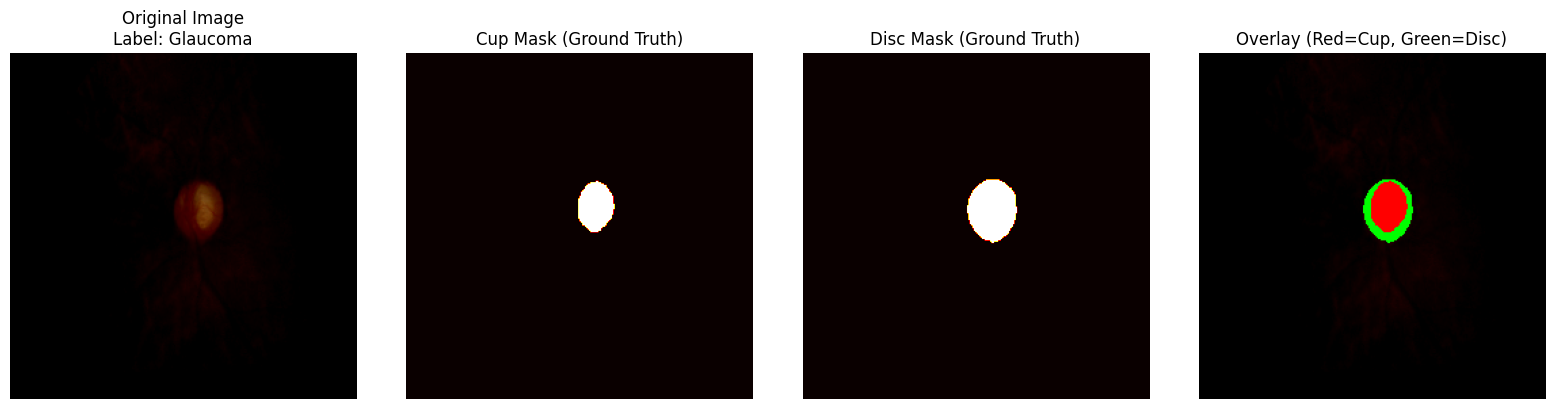

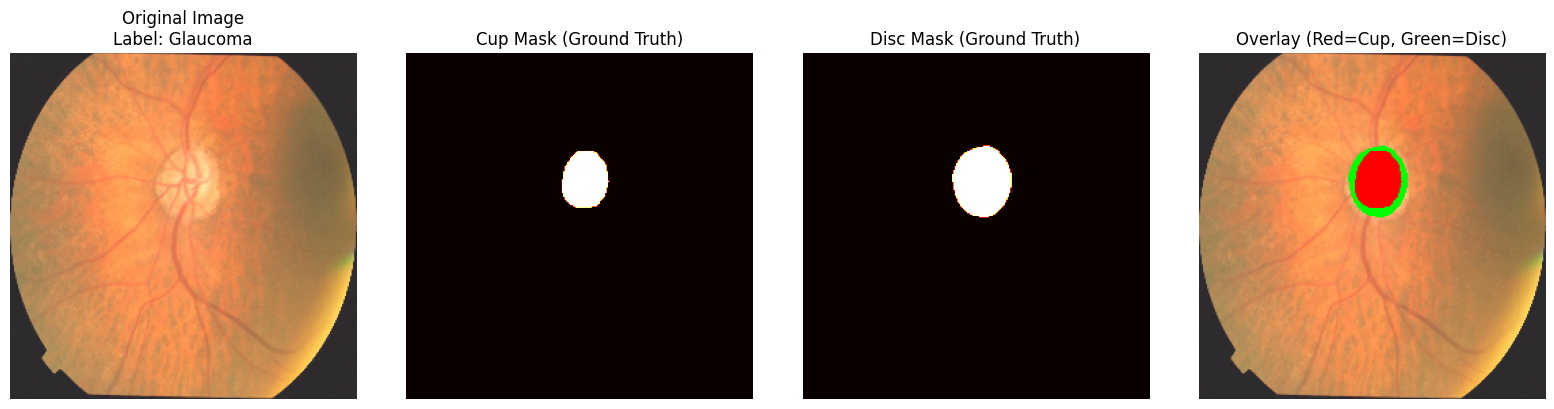

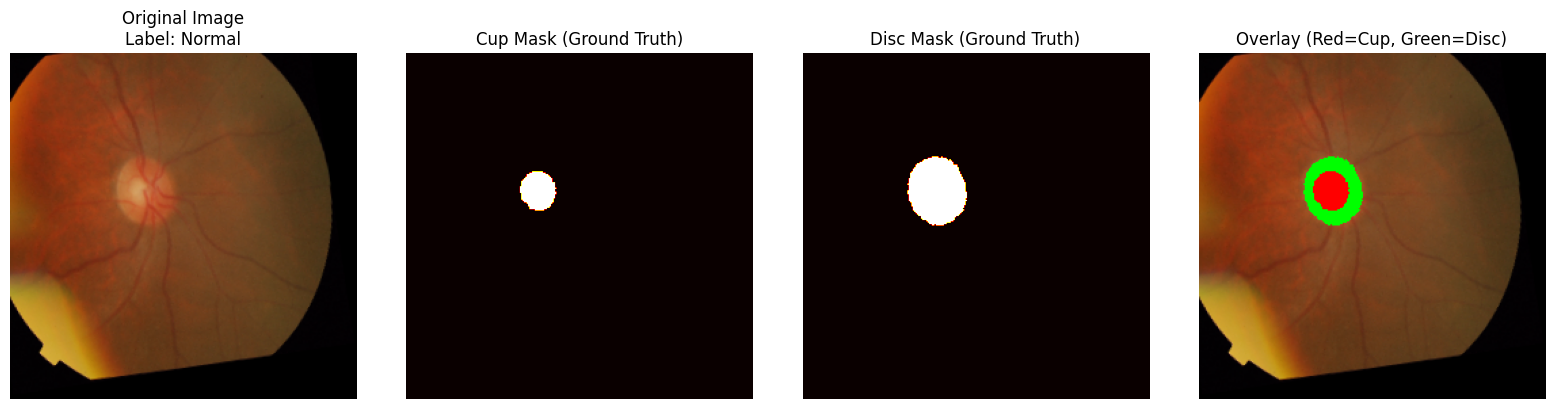

In [30]:
def visualize_sample(dataset, idx=0):
    
    sample = dataset[idx]
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    # Denormalize image for visualization
    image = sample['image'].numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    image = np.clip(image, 0, 1)
    
    axes[0].imshow(image)
    axes[0].set_title(f"Original Image\nLabel: {'Glaucoma' if sample['label'] == 1 else 'Normal'}")
    axes[0].axis('off')
    
    axes[1].imshow(sample['cup_mask'].squeeze(), cmap='hot')
    axes[1].set_title("Cup Mask (Ground Truth)")
    axes[1].axis('off')
    
    axes[2].imshow(sample['disc_mask'].squeeze(), cmap='hot')
    axes[2].set_title("Disc Mask (Ground Truth)")
    axes[2].axis('off')
    
    # Overlay
    overlay = image.copy()
    cup_mask = sample['cup_mask'].squeeze().numpy()
    disc_mask = sample['disc_mask'].squeeze().numpy()
    overlay[disc_mask > 0.5] = [0, 1, 0]  # Green for disc
    overlay[cup_mask > 0.5] = [1, 0, 0]   # Red for cup
    
    axes[3].imshow(overlay)
    axes[3].set_title("Overlay (Red=Cup, Green=Disc)")
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize samples
for i in range(3):
    visualize_sample(train_dataset, i)

In [31]:
# Initialize model
model = GlaucomaUNet(in_channels=config.IN_CHANNELS, bilinear=True)
model = model.to(device)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Train the model
history = train_model(model, train_loader, val_loader, config, device)

Total parameters: 17,410,883
Trainable parameters: 17,410,883

Epoch 1/100
--------------------------------------------------


Validation: 100%|██████████| 13/13 [00:06<00:00,  2.05it/s]


Train Loss: 2.6118 | Val Loss: 210.4062
Train Cup Dice: 0.4744 | Val Cup Dice: 0.0345
Train Disc Dice: 0.4692 | Val Disc Dice: 0.0619
Train Acc: 0.5577 | Val Acc: 0.7308
Val CDR MAE: 0.2727
✓ Best model saved!

Epoch 2/100
--------------------------------------------------


Validation: 100%|██████████| 13/13 [00:06<00:00,  2.07it/s]


Train Loss: 1.4538 | Val Loss: 10.5394
Train Cup Dice: 0.5721 | Val Cup Dice: 0.0872
Train Disc Dice: 0.6148 | Val Disc Dice: 0.1317
Train Acc: 0.5192 | Val Acc: 0.7308
Val CDR MAE: 0.2152
✓ Best model saved!

Epoch 3/100
--------------------------------------------------


...

Train Loss: 0.6787 | Val Loss: 0.6399
Train Cup Dice: 0.8067 | Val Cup Dice: 0.8131
Train Disc Dice: 0.8895 | Val Disc Dice: 0.9145
Train Acc: 0.6346 | Val Acc: 0.7308
Val CDR MAE: 0.1030
No improvement. Patience: 8/10

Epoch 86/100
--------------------------------------------------


Validation: 100%|██████████| 13/13 [00:06<00:00,  1.99it/s]


Train Loss: 0.7073 | Val Loss: 0.6372
Train Cup Dice: 0.7905 | Val Cup Dice: 0.8141
Train Disc Dice: 0.8932 | Val Disc Dice: 0.9160
Train Acc: 0.6538 | Val Acc: 0.7308
Val CDR MAE: 0.0991
No improvement. Patience: 9/10

Epoch 87/100
--------------------------------------------------


Validation: 100%|██████████| 13/13 [00:06<00:00,  2.01it/s]

Train Loss: 0.7077 | Val Loss: 0.6383
Train Cup Dice: 0.7995 | Val Cup Dice: 0.8142
Train Disc Dice: 0.8871 | Val Disc Dice: 0.9134
Train Acc: 0.6154 | Val Acc: 0.7308
Val CDR MAE: 0.0988
No improvement. Patience: 10/10

 Early stopping triggered at epoch 87


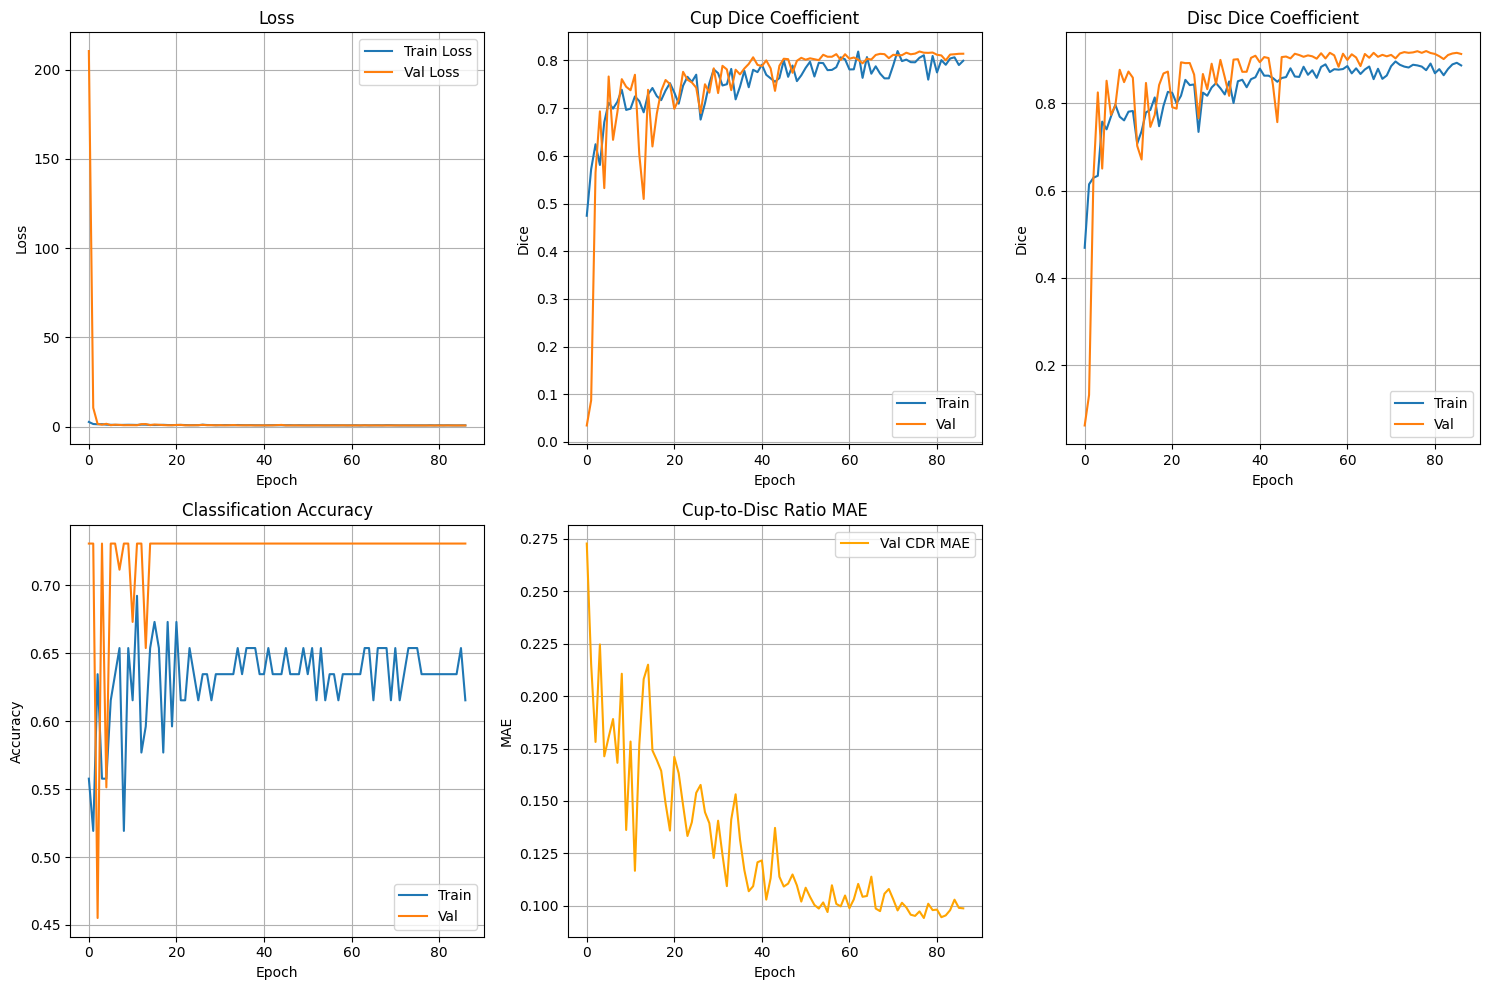

In [32]:
def plot_training_history(history):
    """Plot training metrics"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Loss
    axes[0, 0].plot(history['train_loss'], label='Train Loss')
    axes[0, 0].plot(history['val_loss'], label='Val Loss')
    axes[0, 0].set_title('Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Cup Dice
    axes[0, 1].plot(history['train_cup_dice'], label='Train')
    axes[0, 1].plot(history['val_cup_dice'], label='Val')
    axes[0, 1].set_title('Cup Dice Coefficient')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Dice')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Disc Dice
    axes[0, 2].plot(history['train_disc_dice'], label='Train')
    axes[0, 2].plot(history['val_disc_dice'], label='Val')
    axes[0, 2].set_title('Disc Dice Coefficient')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Dice')
    axes[0, 2].legend()
    axes[0, 2].grid(True)
    
    # Accuracy
    axes[1, 0].plot(history['train_acc'], label='Train')
    axes[1, 0].plot(history['val_acc'], label='Val')
    axes[1, 0].set_title('Classification Accuracy')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True)
    
    # CDR MAE
    axes[1, 1].plot(history['val_cdr_mae'], label='Val CDR MAE', color='orange')
    axes[1, 1].set_title('Cup-to-Disc Ratio MAE')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('MAE')
    axes[1, 1].legend()
    axes[1, 1].grid(True)
    
    # Hide last subplot
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150)
    plt.show()

plot_training_history(history)

Loaded best model from epoch 77
Validation metrics: {'loss': 0.6251370562956884, 'cup_dice': 0.8188571196336013, 'disc_dice': 0.919732350569505, 'cup_iou': 0.7031724773920499, 'disc_iou': 0.8531471353310806, 'accuracy': 0.7307692307692307, 'cdr_mae': 0.09736647399572226}


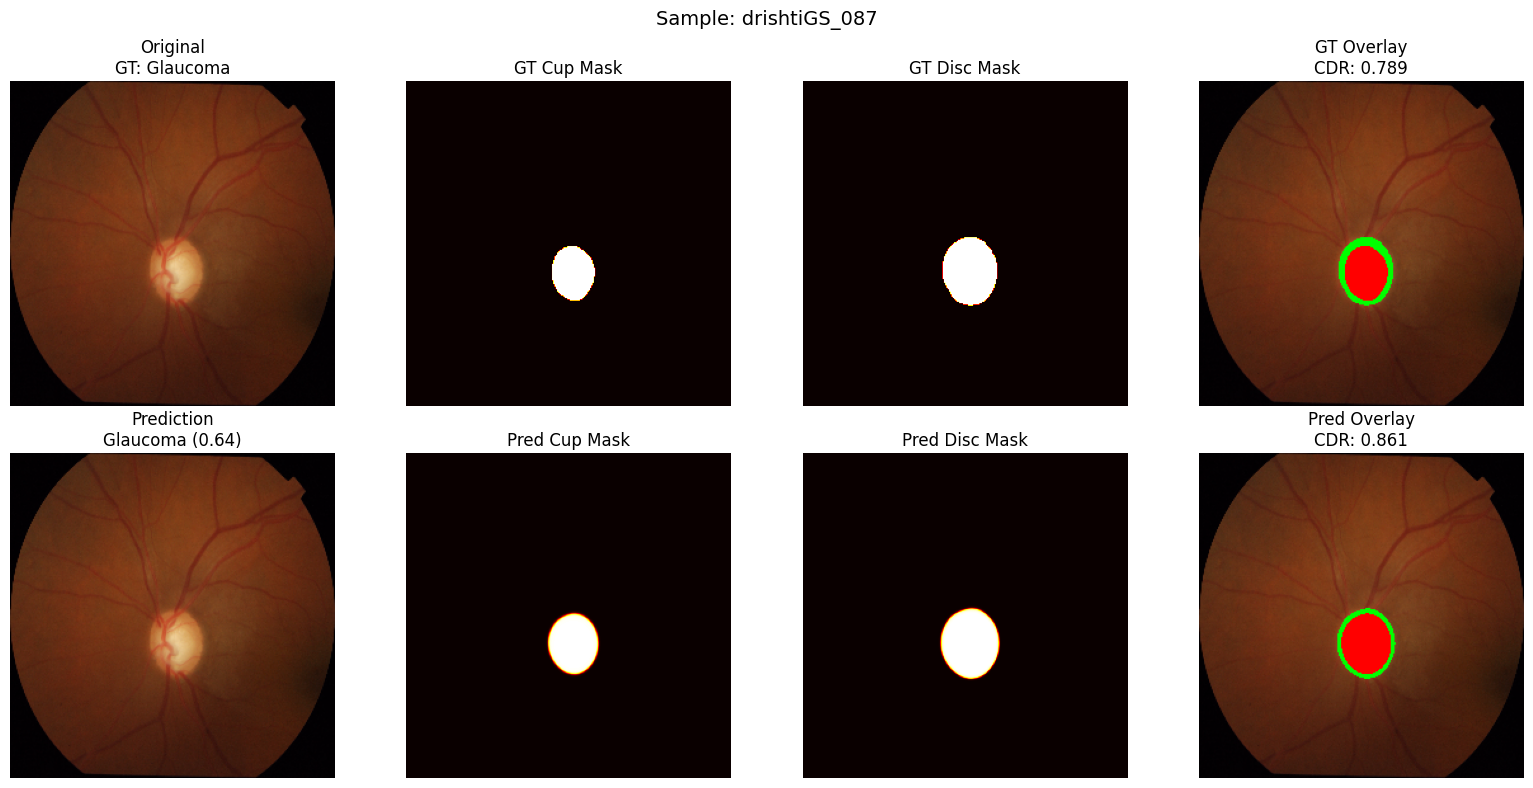

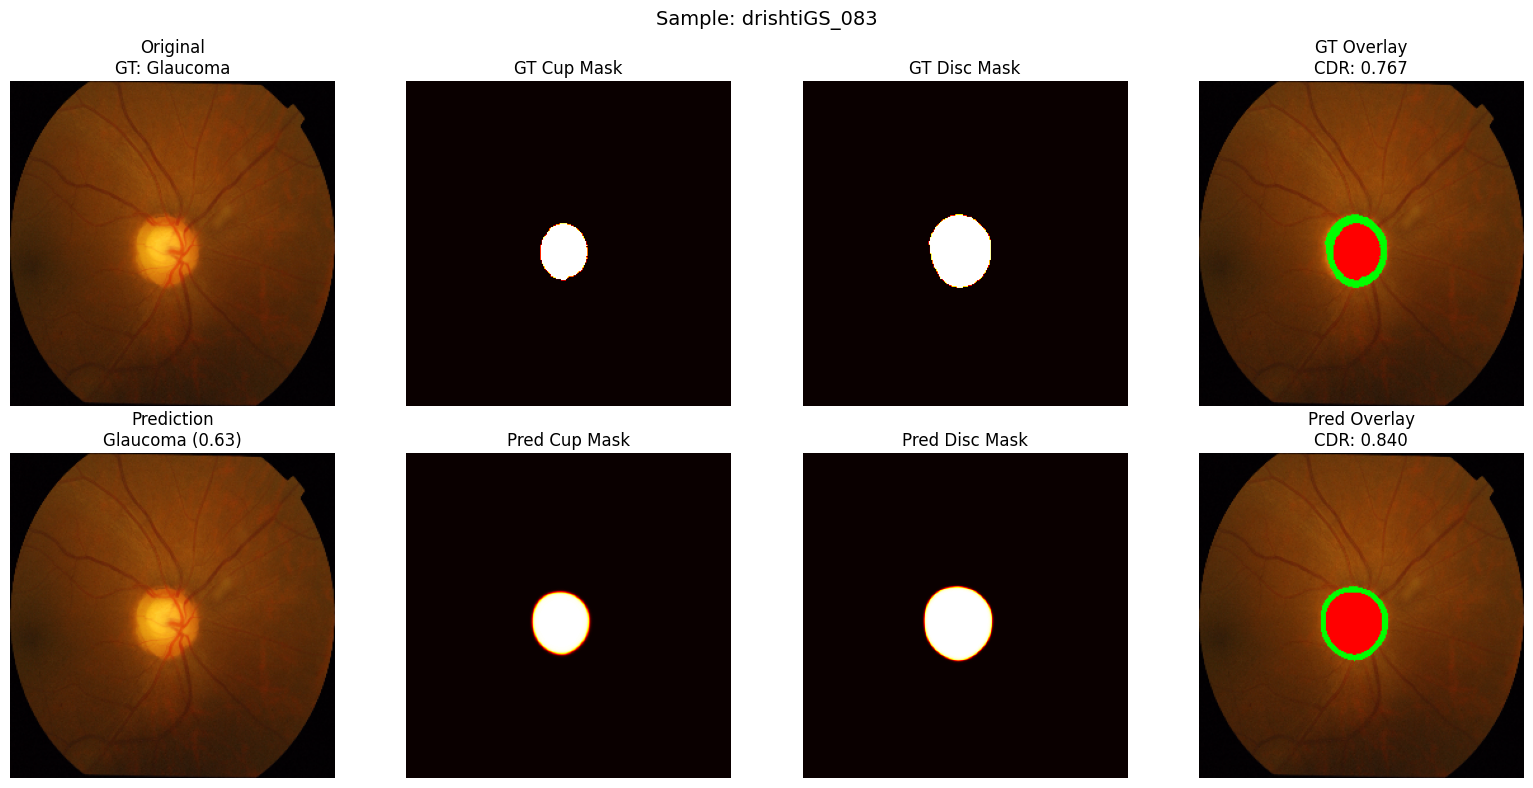

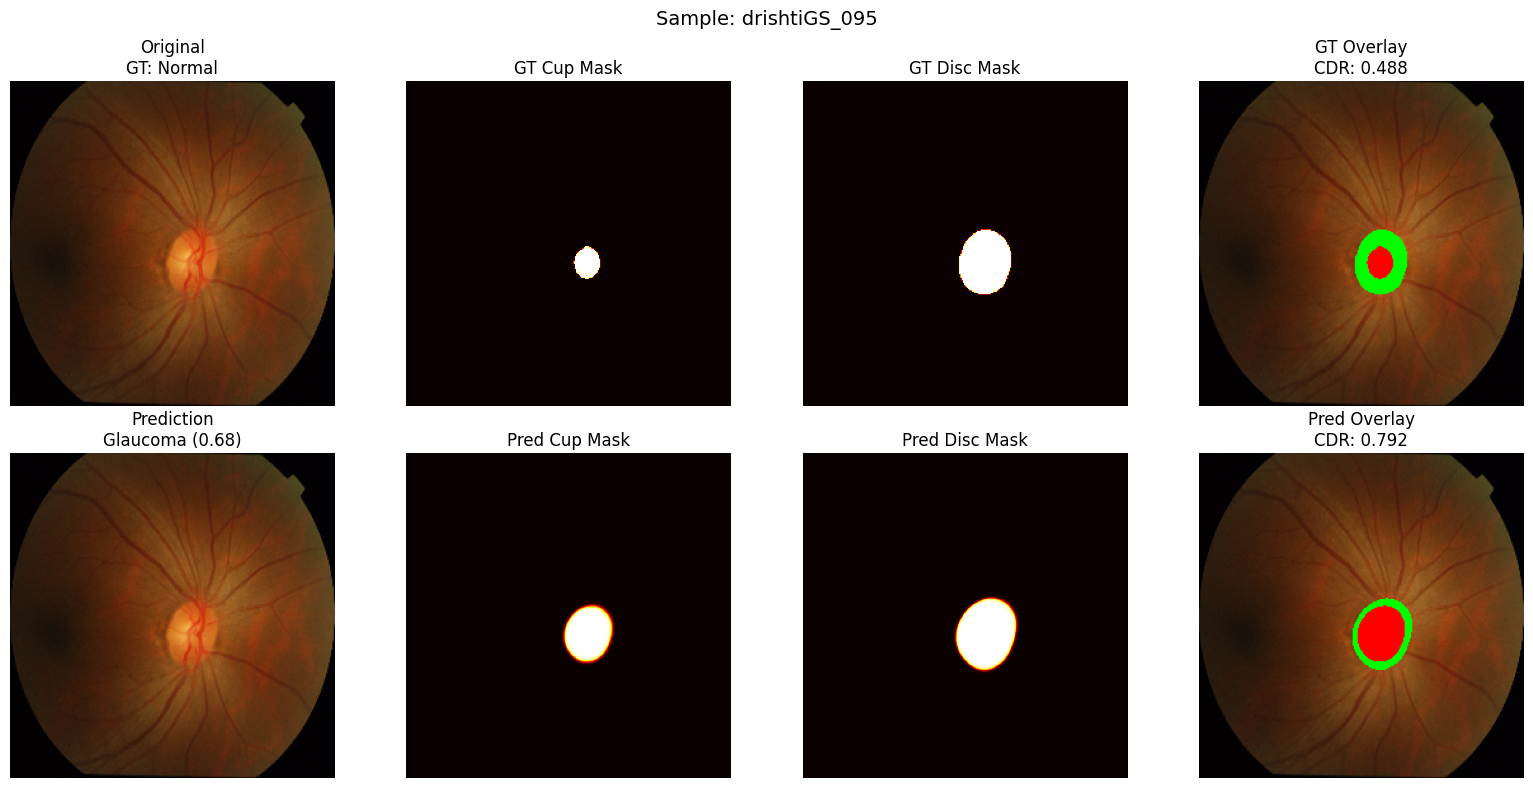

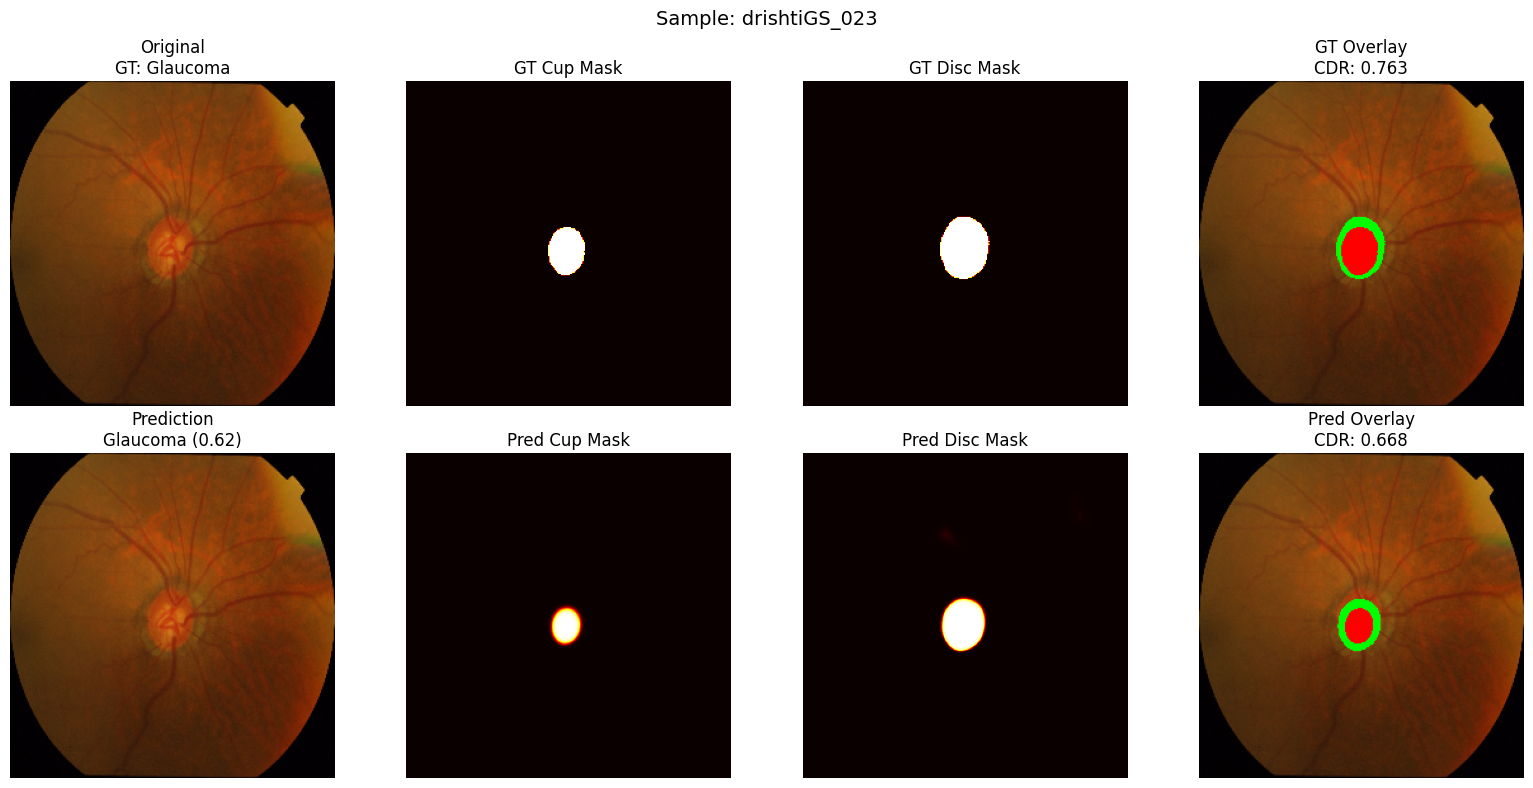

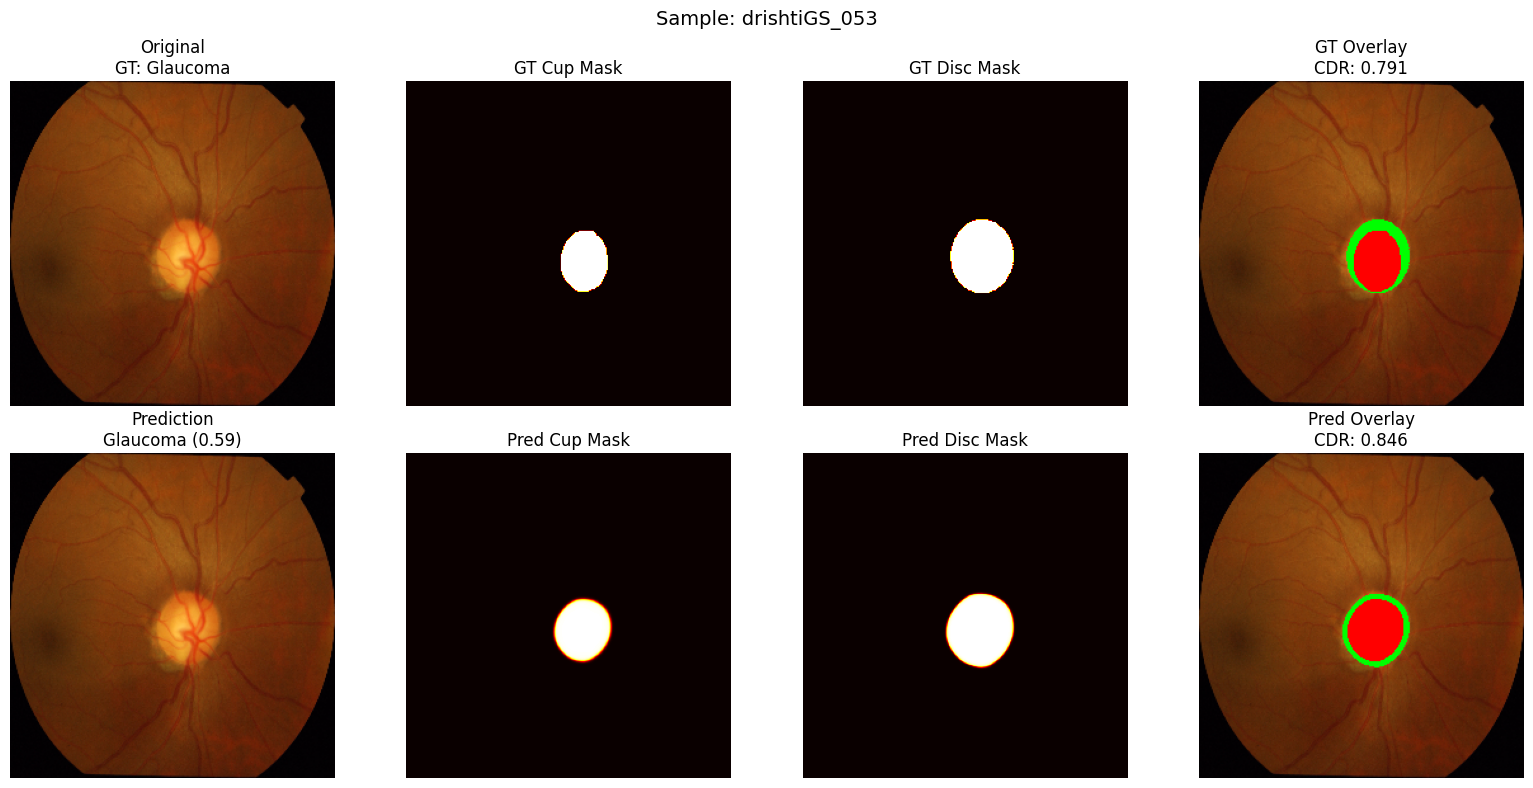

In [33]:
def predict_and_visualize(model, dataset, device, num_samples=5):
    """Run inference and visualize results"""
    model.eval()
    
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    for idx in indices:
        sample = dataset[idx]
        image = sample['image'].unsqueeze(0).to(device)
        
        with torch.no_grad():
            outputs = model(image)
        
        # Get predictions
        cup_pred = outputs['cup_mask'].cpu().squeeze().numpy()
        disc_pred = outputs['disc_mask'].cpu().squeeze().numpy()
        cls_pred = outputs['classification'].cpu().item()
        
        # Calculate CDR
        pred_cdr = GlaucomaUNet.calculate_cdr(
            outputs['cup_mask'], outputs['disc_mask']
        ).cpu().item()
        
        gt_cdr = GlaucomaUNet.calculate_cdr(
            sample['cup_mask'].unsqueeze(0), 
            sample['disc_mask'].unsqueeze(0)
        ).item()
        
        # Visualize
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        
        # Denormalize image
        img = sample['image'].numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        # Row 1: Ground Truth
        axes[0, 0].imshow(img)
        gt_label = 'Glaucoma' if sample['label'] == 1 else 'Normal'
        axes[0, 0].set_title(f"Original\nGT: {gt_label}")
        axes[0, 0].axis('off')
        
        axes[0, 1].imshow(sample['cup_mask'].squeeze(), cmap='hot')
        axes[0, 1].set_title("GT Cup Mask")
        axes[0, 1].axis('off')
        
        axes[0, 2].imshow(sample['disc_mask'].squeeze(), cmap='hot')
        axes[0, 2].set_title("GT Disc Mask")
        axes[0, 2].axis('off')
        
        gt_overlay = img.copy()
        gt_cup = sample['cup_mask'].squeeze().numpy()
        gt_disc = sample['disc_mask'].squeeze().numpy()
        gt_overlay[gt_disc > 0.5] = [0, 1, 0]
        gt_overlay[gt_cup > 0.5] = [1, 0, 0]
        axes[0, 3].imshow(gt_overlay)
        axes[0, 3].set_title(f"GT Overlay\nCDR: {gt_cdr:.3f}")
        axes[0, 3].axis('off')
        
        # Row 2: Predictions
        pred_label = 'Glaucoma' if cls_pred > 0.5 else 'Normal'
        axes[1, 0].imshow(img)
        axes[1, 0].set_title(f"Prediction\n{pred_label} ({cls_pred:.2f})")
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(cup_pred, cmap='hot')
        axes[1, 1].set_title("Pred Cup Mask")
        axes[1, 1].axis('off')
        
        axes[1, 2].imshow(disc_pred, cmap='hot')
        axes[1, 2].set_title("Pred Disc Mask")
        axes[1, 2].axis('off')
        
        pred_overlay = img.copy()
        pred_overlay[disc_pred > 0.5] = [0, 1, 0]
        pred_overlay[cup_pred > 0.5] = [1, 0, 0]
        axes[1, 3].imshow(pred_overlay)
        axes[1, 3].set_title(f"Pred Overlay\nCDR: {pred_cdr:.3f}")
        axes[1, 3].axis('off')
        
        plt.suptitle(f"Sample: {sample['img_id']}", fontsize=14)
        plt.tight_layout()
        plt.show()

# Load best model and visualize
checkpoint = torch.load('best_glaucoma_unet.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"Validation metrics: {checkpoint['val_metrics']}")

predict_and_visualize(model, val_dataset, device, num_samples=5)

In [34]:
@torch.no_grad()
def evaluate_model(model, dataloader, device):
    """Complete evaluation with all metrics"""
    model.eval()
    
    all_cup_dice = []
    all_disc_dice = []
    all_cup_iou = []
    all_disc_iou = []
    all_pred_labels = []
    all_true_labels = []
    all_pred_cdr = []
    all_gt_cdr = []
    
    for batch in tqdm(dataloader, desc='Evaluating'):
        images = batch['image'].to(device)
        cup_masks = batch['cup_mask'].to(device)
        disc_masks = batch['disc_mask'].to(device)
        labels = batch['label'].to(device)
        
        outputs = model(images)
        
        # Metrics for each sample in batch
        for i in range(images.size(0)):
            all_cup_dice.append(dice_coefficient(
                outputs['cup_mask'][i:i+1], cup_masks[i:i+1]
            ))
            all_disc_dice.append(dice_coefficient(
                outputs['disc_mask'][i:i+1], disc_masks[i:i+1]
            ))
            all_cup_iou.append(iou_score(
                outputs['cup_mask'][i:i+1], cup_masks[i:i+1]
            ))
            all_disc_iou.append(iou_score(
                outputs['disc_mask'][i:i+1], disc_masks[i:i+1]
            ))
            
            all_pred_labels.append((outputs['classification'][i] > 0.5).float().item())
            all_true_labels.append(labels[i].item())
            
            # CDR
            pred_cdr = GlaucomaUNet.calculate_cdr(
                outputs['cup_mask'][i:i+1], outputs['disc_mask'][i:i+1]
            ).item()
            gt_cdr = GlaucomaUNet.calculate_cdr(
                cup_masks[i:i+1], disc_masks[i:i+1]
            ).item()
            all_pred_cdr.append(pred_cdr)
            all_gt_cdr.append(gt_cdr)
    
    # Calculate final metrics
    results = {
        'Cup Dice': np.mean(all_cup_dice),
        'Cup Dice Std': np.std(all_cup_dice),
        'Disc Dice': np.mean(all_disc_dice),
        'Disc Dice Std': np.std(all_disc_dice),
        'Cup IoU': np.mean(all_cup_iou),
        'Disc IoU': np.mean(all_disc_iou),
        'Classification Accuracy': np.mean(np.array(all_pred_labels) == np.array(all_true_labels)),
        'CDR MAE': np.mean(np.abs(np.array(all_pred_cdr) - np.array(all_gt_cdr))),
        'CDR Correlation': np.corrcoef(all_pred_cdr, all_gt_cdr)[0, 1]
    }
    
    return results, all_pred_cdr, all_gt_cdr, all_pred_labels, all_true_labels

# Run evaluation
results, pred_cdr, gt_cdr, pred_labels, true_labels = evaluate_model(model, val_loader, device)

print("\n" + "="*60)
print("FINAL EVALUATION RESULTS")
print("="*60)
for metric, value in results.items():
    print(f"{metric}: {value:.4f}")
print("="*60)

Evaluating: 100%|██████████| 13/13 [00:06<00:00,  1.96it/s]


FINAL EVALUATION RESULTS
Cup Dice: 0.8173
Cup Dice Std: 0.1286
Disc Dice: 0.9203
Disc Dice Std: 0.0615
Cup IoU: 0.7089
Disc IoU: 0.8576
Classification Accuracy: 0.7451
CDR MAE: 0.0944
CDR Correlation: 0.3343


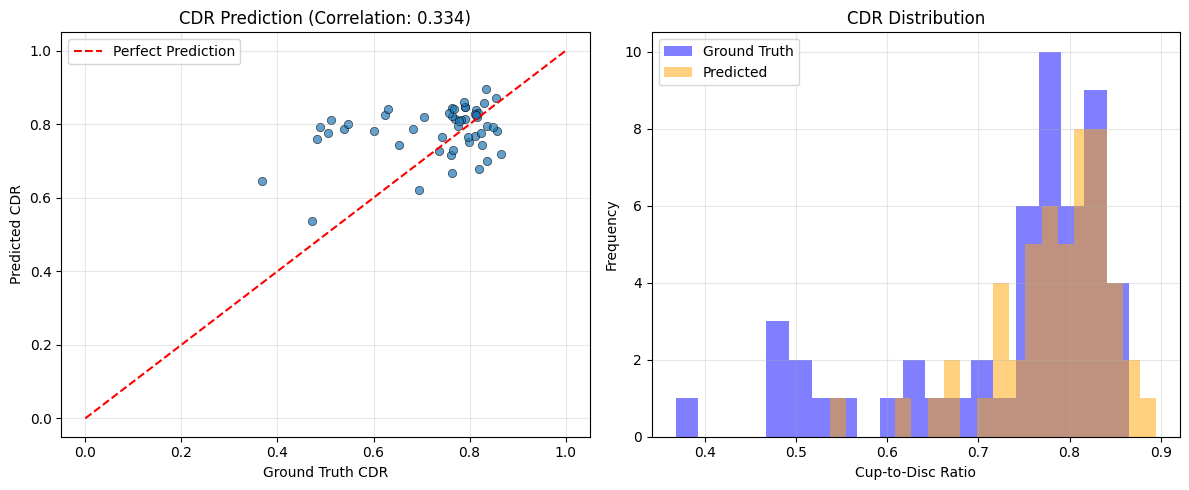


CLINICAL INTERPRETATION OF CDR
CDR < 0.3: Normal (Low risk)
CDR 0.3-0.5: Borderline (Moderate risk)
CDR > 0.5: Suspicious for Glaucoma (High risk)


In [35]:
# Plot CDR correlation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CDR Scatter plot
axes[0].scatter(gt_cdr, pred_cdr, alpha=0.7, edgecolors='black', linewidth=0.5)
axes[0].plot([0, 1], [0, 1], 'r--', label='Perfect Prediction')
axes[0].set_xlabel('Ground Truth CDR')
axes[0].set_ylabel('Predicted CDR')
axes[0].set_title(f'CDR Prediction (Correlation: {results["CDR Correlation"]:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CDR Distribution
axes[1].hist(gt_cdr, bins=20, alpha=0.5, label='Ground Truth', color='blue')
axes[1].hist(pred_cdr, bins=20, alpha=0.5, label='Predicted', color='orange')
axes[1].set_xlabel('Cup-to-Disc Ratio')
axes[1].set_ylabel('Frequency')
axes[1].set_title('CDR Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cdr_analysis.png', dpi=150)
plt.show()

# Clinical interpretation
print("\n" + "="*60)
print("CLINICAL INTERPRETATION OF CDR")
print("="*60)
print("CDR < 0.3: Normal (Low risk)")
print("CDR 0.3-0.5: Borderline (Moderate risk)")
print("CDR > 0.5: Suspicious for Glaucoma (High risk)")
print("="*60)

In [36]:
def predict_single_image(model, image_path, device, img_size=256):
   
    model.eval()
    
    # Load and preprocess image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    original_size = image.shape[:2]
    
    # Apply transforms
    transform = get_val_transforms(img_size)
    augmented = transform(image=image)
    input_tensor = augmented['image'].unsqueeze(0).to(device)
    
    # Inference
    with torch.no_grad():
        outputs = model(input_tensor)
    
    # Get predictions
    cup_mask = outputs['cup_mask'].cpu().squeeze().numpy()
    disc_mask = outputs['disc_mask'].cpu().squeeze().numpy()
    glaucoma_prob = outputs['classification'].cpu().item()
    
    # Calculate CDR
    cdr = GlaucomaUNet.calculate_cdr(
        outputs['cup_mask'], outputs['disc_mask']
    ).cpu().item()
    
    # Resize masks to original size
    cup_mask_resized = cv2.resize(cup_mask, (original_size[1], original_size[0]))
    disc_mask_resized = cv2.resize(disc_mask, (original_size[1], original_size[0]))
    
    # Determine diagnosis
    if glaucoma_prob > 0.5:
        diagnosis = "GLAUCOMA SUSPECTED"
        risk_level = "HIGH"
    elif cdr > 0.5:
        diagnosis = "ELEVATED CDR - Monitor closely"
        risk_level = "MODERATE"
    else:
        diagnosis = "NORMAL"
        risk_level = "LOW"
    
    return {
        'cup_mask': cup_mask_resized,
        'disc_mask': disc_mask_resized,
        'glaucoma_probability': glaucoma_prob,
        'cup_to_disc_ratio': cdr,
        'diagnosis': diagnosis,
        'risk_level': risk_level
    }


def visualize_prediction(image_path, prediction):
    """Visualize prediction results"""
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(image)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(prediction['cup_mask'], cmap='hot')
    axes[1].set_title('Cup Segmentation')
    axes[1].axis('off')
    
    axes[2].imshow(prediction['disc_mask'], cmap='hot')
    axes[2].set_title('Disc Segmentation')
    axes[2].axis('off')
    
    # Create overlay
    overlay = image.copy().astype(float) / 255.0
    disc_mask = prediction['disc_mask'] > 0.5
    cup_mask = prediction['cup_mask'] > 0.5
    overlay[disc_mask] = [0, 1, 0]  # Green for disc
    overlay[cup_mask] = [1, 0, 0]   # Red for cup
    
    axes[3].imshow(overlay)
    axes[3].set_title(f"Overlay\nCDR: {prediction['cup_to_disc_ratio']:.3f}")
    axes[3].axis('off')
    
    plt.suptitle(
        f"Diagnosis: {prediction['diagnosis']} | "
        f"Glaucoma Prob: {prediction['glaucoma_probability']:.2%} | "
        f"Risk: {prediction['risk_level']}",
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

# Example usage (uncomment to run)
# prediction = predict_single_image(model, 'path/to/image.png', device)
# visualize_prediction('path/to/image.png', prediction)

In [37]:
# =============================================================================
# SAVE MODEL FOR KAGGLE DEPLOYMENT
# =============================================================================

# Save complete model (architecture + weights)
torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'in_channels': config.IN_CHANNELS,
        'img_size': config.IMG_SIZE,
        'bilinear': True
    }
}, 'glaucoma_unet_complete.pth')

print("Model saved successfully!")
print("\nTo load the model:")
print("```python")
print("checkpoint = torch.load('glaucoma_unet_complete.pth')")
print("model = GlaucomaUNet(in_channels=3, bilinear=True)")
print("model.load_state_dict(checkpoint['model_state_dict'])")
print("model.eval()")
print("```")

Model saved successfully!

To load the model:
```python
checkpoint = torch.load('glaucoma_unet_complete.pth')
model = GlaucomaUNet(in_channels=3, bilinear=True)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
```
